# 📊 Amazon Orders Exploratory Data Analysis (2020–2024)

This notebook performs **Exploratory Data Analysis (EDA)** on the cleaned Amazon orders dataset covering the period **2020–2024**.

## 🔍 Purpose of This Notebook

The goal of this notebook is to analyze the cleaned dataset produced in **Notebook 02 – Data Cleaning**.
Through systematic exploration and visualization, we aim to better understand the dataset and uncover patterns that can inform business insights and future modeling tasks.

## 🎯 Objectives of the Analysis

The main objectives of this exploratory analysis are:

### 1️⃣ Understand Data Distribution

Examine how numerical and categorical variables are distributed using statistical summaries and visualizations.

### 2️⃣ Identify Trends and Patterns

Explore relationships between variables to identify meaningful trends such as sales behavior, customer activity, and product performance.

### 3️⃣ Detect Anomalies and Outliers

Identify unusual values or extreme observations that may impact analysis or modeling.

### 4️⃣ Generate Business Insights

Derive insights related to:

* product performance
* customer purchasing behavior
* geographic trends
* payment preferences

These insights can support **data-driven decision making**.

### 5️⃣ Prepare for Feature Engineering

Identify potential transformations and engineered features that will improve the effectiveness of downstream machine learning models.

## 📊 Expected Outcome

By the end of this notebook, we will have a **clear understanding of the dataset's structure, distributions, and key behavioral patterns**.
These insights will guide the next stage of the project: **feature engineering and predictive modeling**.


## Load Processed Data

We import the dataset and variables generated during the data cleaning phase.

This ensures that exploratory data analysis (EDA) builds directly on the cleaned and validated dataset.

In [0]:
%run /Workspace/Amazon_project/02_data_cleaning

# 🧹 Amazon Orders Data Pipeline (2020–2024)
## 🧩 Notebook 02 — Data Cleaning

---

## 🔗 Dependency

This notebook depends on:

%run /Workspace/Amazon_project/01_data_ingestion_and_validation

Notebook 01 performs:
- Environment initialization
- Schema enforcement
- Structural validation
- Business rule validation

This notebook focuses on transforming validated raw data into a clean analytical dataset.

---

## 🎯 Objective

The goal of this notebook is to:

1. Handle missing values
2. Remove duplicates
3. Correct invalid records
4. Standardize categorical values
5. Normalize text fields
6. Prepare a clean dataset for EDA and feature engineering

The output of this notebook is a cleaned DataFrame.

# 📦 Amazon Orders Data Pipeline (2020–2024)
## 🧩 Notebook 01 — Data Ingestion & Validation

---

## 🔍 Project Overview

This project analyzes Amazon transactional order data spanning **January 1, 2020 to December 29, 2024**.  
The dataset contains transaction-level information including:

- Order details
- Customer information
- Product attributes
- Pricing & discounts
- Taxes & shipping costs
- Payment methods
- Order status
- Geographic information

The overall objective of this project is to extract actionable business insights related to:

- 📈 Sales performance trends  
- 🛍️ Product & category performance  
- 👥 Customer purchasing behavior  
- 💳 Payment method usage  
- 🚚 Shipping & tax impact  
- 🌍 Regional distribution  
- 🏷️ Pricing and discount patterns  

---

## 🏗 Role of This Notebook in the Pipeline

This notebook is responsible for:

1. Initializing the data processing environment
2. Enforcing schema consistency
3. Ingesting the raw dataset
4. Performing structured data validation checks
5. Preparing a clean base DataFrame for downstream analysis

This notebook must be executed before running:

- 02_data_cleaning  
- 03_exploratory_data_analysis  
- 04_feature_engineering  
- 05_statistical_testing  
- 06_ml_modeling  

It serves as the **foundation layer** of the end-to-end analytics pipeline.

---

## 🛠 Tools & Technologies

The following technologies are used across the project:

- **NumPy** – Numerical computations  
- **Pandas** – Data manipulation  
- **Matplotlib & Seaborn** – Data visualization  
- **PySpark** – Distributed data processing  
- **Scikit-learn** – Feature scaling & modeling  
- **SciPy & Statsmodels** – Statistical analysis  

PySpark enables scalable ingestion and validation of large transactional datasets, while Python-based libraries support statistical modeling and visualization in later stages.

---

> 📌 Note: This notebook establishes the trusted base dataset for all downstream analytics, feature engineering, and machine learning workflows.

## 🔧 Environment Initialization

This notebook initializes:
- Spark session
- Required Python libraries
- Shared schema definitions

It acts as the foundational setup notebook for all subsequent analysis notebooks.

### 🏗 Schema Enforcement Strategy

An explicit schema is defined using `StructType` to ensure:

- Data type consistency
- Prevention of incorrect inference
- Improved performance
- Stronger validation controls

Schema enforcement prevents silent data corruption during ingestion.


Rows : 100000 , Columns : 20



## 🔎 Data Validation Framework

The following validation checks are performed:

1. Structural Validation
   - Schema verification
   - Column count validation

2. Completeness Checks
   - Null value assessment
   - Missing critical fields detection

3. Uniqueness Checks
   - Duplicate OrderID detection

4. Range & Constraint Checks
   - Quantity > 0
   - Price >= 0
   - Tax >= 0
   - Shipping Cost >= 0

5. Date Validation
   - Valid date parsing
   - Date range within expected bounds

6. Business Rule Validation
   - Order status validity
   - Payment method consistency

Any validation failures will be logged for review.


Amazon Orders Table Schema

root
 |-- OrderID: string (nullable = true)
 |-- OrderDate: date (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- CustomerName: string (nullable = true)
 |-- ProductID: string (nullable = true)
 |-- ProductName: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Brand: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- Discount: double (nullable = true)
 |-- Tax: double (nullable = true)
 |-- ShippingCost: double (nullable = true)
 |-- TotalAmount: double (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- OrderStatus: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- SellerID: string (nullable = true)



In [0]:
print("Number of records:", df.count())
print("Number of columns:", len(df.columns))

display(df.limit(10))
df.printSchema()

Number of records: 100000
Number of columns: 20


OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,CREDIT CARD,Cancelled,San Antonio,Tx,CANADA,SELL01411
ORD0000058,2024-02-17,CUST040925,Vivaan Verma,P00005,Laptop Sleeve,Clothing,UrbanStyle,5,182.55,0.0,45.64,12.08,970.47,UPI,Delivered,San Diego,Ca,CANADA,SELL01920
ORD0000076,2022-08-13,CUST042061,Mohit Reddy,P00010,Smartwatch,Clothing,CoreTech,4,437.47,0.0,314.98,8.82,2073.68,CREDIT CARD,Shipped,Philadelphia,Pa,CANADA,SELL01119
ORD0000125,2020-03-05,CUST009308,Vihaan Sharma,P00021,Backpack,Sports & Outdoors,HomeEase,5,200.05,0.05,114.03,2.34,1066.61,CREDIT CARD,Delivered,Houston,Tx,UNITED KINGDOM,SELL00770
ORD0000147,2020-07-19,CUST037485,Kabir Verma,P00015,Instant Pot,Electronics,KiddoFun,1,194.17,0.0,9.71,5.33,209.21,CREDIT CARD,Delivered,San Francisco,Ca,INDIA,SELL01097
ORD0000186,2022-10-17,CUST021204,Pooja Singh,P00042,Projector Mini,Toys & Games,UrbanStyle,2,495.32,0.0,49.53,10.01,1050.18,CREDIT CARD,Pending,Phoenix,Az,UNITED STATES,SELL01469
ORD0000190,2023-12-01,CUST034016,Aditya Singh,P00046,Car Charger,Sports & Outdoors,Zenith,3,416.84,0.15,85.04,14.4,1162.38,DEBIT CARD,Delivered,Phoenix,Az,UNITED STATES,SELL01532
ORD0000198,2023-03-29,CUST027565,Sneha Verma,P00019,LED Desk Lamp,Home & Kitchen,CoreTech,2,387.31,0.0,92.95,7.12,874.69,DEBIT CARD,Delivered,San Francisco,Ca,UNITED STATES,SELL01488
ORD0000217,2024-03-09,CUST019363,Sunita Reddy,P00005,Laptop Sleeve,Toys & Games,FitLife,5,470.82,0.1,169.5,12.39,2300.58,DEBIT CARD,Delivered,Denver,Co,UNITED STATES,SELL01565
ORD0000233,2024-01-19,CUST028877,Anjali Kapoor,P00005,Laptop Sleeve,Home & Kitchen,UrbanStyle,3,512.13,0.0,122.91,14.93,1674.23,NET BANKING,Delivered,Chicago,Il,UNITED STATES,SELL00809


root
 |-- OrderID: string (nullable = true)
 |-- OrderDate: date (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- CustomerName: string (nullable = true)
 |-- ProductID: string (nullable = true)
 |-- ProductName: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Brand: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- Discount: double (nullable = false)
 |-- Tax: double (nullable = false)
 |-- ShippingCost: double (nullable = false)
 |-- TotalAmount: double (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- OrderStatus: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- SellerID: string (nullable = true)



### 🔹Schema Validation

✔ Column count validation passed.


...

### 🔹  Fix Invalid Numeric Values

Total Records: 100000
Integrity Failures: 0 (0.00%)


### 🔹 Standardize Categorical Columns

OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,CREDIT CARD,Cancelled,San Antonio,Tx,CANADA,SELL01411
ORD0000058,2024-02-17,CUST040925,Vivaan Verma,P00005,Laptop Sleeve,Clothing,UrbanStyle,5,182.55,0.0,45.64,12.08,970.47,UPI,Delivered,San Diego,Ca,CANADA,SELL01920
ORD0000076,2022-08-13,CUST042061,Mohit Reddy,P00010,Smartwatch,Clothing,CoreTech,4,437.47,0.0,314.98,8.82,2073.68,CREDIT CARD,Shipped,Philadelphia,Pa,CANADA,SELL01119
ORD0000125,2020-03-05,CUST009308,Vihaan Sharma,P00021,Backpack,Sports & Outdoors,HomeEase,5,200.05,0.05,114.03,2.34,1066.61,CREDIT CARD,Delivered,Houston,Tx,UNITED KINGDOM,SELL00770
ORD0000147,2020-07-19,CUST037485,Kabir Verma,P00015,Instant Pot,Electronics,KiddoFun,1,194.17,0.0,9.71,5.33,209.21,CREDIT CARD,Delivered,San Francisco,Ca,INDIA,SELL01097
ORD0000186,2022-10-17,CUST021204,Pooja Singh,P00042,Projector Mini,Toys & Games,UrbanStyle,2,495.32,0.0,49.53,10.01,1050.18,CREDIT CARD,Pending,Phoenix,Az,UNITED STATES,SELL01469
ORD0000190,2023-12-01,CUST034016,Aditya Singh,P00046,Car Charger,Sports & Outdoors,Zenith,3,416.84,0.15,85.04,14.4,1162.38,DEBIT CARD,Delivered,Phoenix,Az,UNITED STATES,SELL01532
ORD0000198,2023-03-29,CUST027565,Sneha Verma,P00019,LED Desk Lamp,Home & Kitchen,CoreTech,2,387.31,0.0,92.95,7.12,874.69,DEBIT CARD,Delivered,San Francisco,Ca,UNITED STATES,SELL01488
ORD0000217,2024-03-09,CUST019363,Sunita Reddy,P00005,Laptop Sleeve,Toys & Games,FitLife,5,470.82,0.1,169.5,12.39,2300.58,DEBIT CARD,Delivered,Denver,Co,UNITED STATES,SELL01565
ORD0000233,2024-01-19,CUST028877,Anjali Kapoor,P00005,Laptop Sleeve,Home & Kitchen,UrbanStyle,3,512.13,0.0,122.91,14.93,1674.23,NET BANKING,Delivered,Chicago,Il,UNITED STATES,SELL00809


## 📊 Cleaning Summary

The following cleaning steps were performed:

- Duplicate orders removed
- Critical null records dropped
- Non-critical null values imputed
- Invalid numeric values filtered
- Categorical values standardized
- Date range validated

The resulting clean dataset is now ready for exploratory data analysis.

## 📦 Order Quantity, Pricing & Cost Insights

### Objective
The goal of this analysis is to understand the distribution and variability of key transactional metrics in the Amazon orders dataset. By analyzing statistical properties such as averages, medians, ranges, and variability, we can uncover patterns in customer purchasing behavior, pricing strategies, and operational costs.

This section provides a comprehensive statistical overview of key financial and transactional metrics including **order quantity, unit pricing, discounts, taxes, shipping costs, and total order value**.

## 📊 Metrics Analyzed

The following numerical features are analyzed:

- **Quantity** – number of units purchased per order  
- **UnitPrice** – price per product unit  
- **TotalAmount** – final value of the order  
- **Discount** – promotional reduction applied  
- **Tax** – tax applied to the order  
- **ShippingCost** – logistics cost associated with delivery



In [0]:
detailed_stats = df.select(
    # Quantity stats
    f.max("Quantity").alias("max_qty"),
    f.min("Quantity").alias("min_qty"),
    f.avg("Quantity").alias("avg_qty"),
    f.expr("percentile_approx(Quantity, 0.5)").alias("median_qty"),
    f.stddev("Quantity").alias("std_qty"),
    
    # Pricing stats
    f.max("UnitPrice").alias("max_unit_price"),
    f.min("UnitPrice").alias("min_unit_price"),
    f.avg("UnitPrice").alias("avg_unit_price"),
    f.expr("percentile_approx(UnitPrice, 0.5)").alias("median_unit_price"),
    f.stddev("UnitPrice").alias("std_unit_price"),
    
    # Order value stats
    f.max("TotalAmount").alias("max_order_value"),
    f.min("TotalAmount").alias("min_order_value"),
    f.avg("TotalAmount").alias("avg_order_value"),
    f.expr("percentile_approx(TotalAmount, 0.5)").alias("median_order_value"),

    # Discount stats
    f.max("Discount").alias("max_discount"),
    f.min("Discount").alias("min_discount"),
    f.avg("Discount").alias("avg_discount"),
    f.expr("percentile_approx(Discount, 0.5)").alias("median_discount"),

    # Tax stats
    f.max("Tax").alias("max_tax"),
    f.min("Tax").alias("min_tax"),
    f.avg("Tax").alias("avg_tax"),
    f.expr("percentile_approx(Tax, 0.5)").alias("median_tax"),

    # Shipping cost stats
    f.max("ShippingCost").alias("max_shipping_cost"),
    f.min("ShippingCost").alias("min_shipping_cost"),
    f.avg("ShippingCost").alias("avg_shipping_cost"),
    f.expr("percentile_approx(ShippingCost, 0.5)").alias("median_shipping_cost")
).collect()[0]

In [0]:
print("📦 Quantity Insights")
print(f"  • Max Quantity Ordered     : {detailed_stats['max_qty']}")
print(f"  • Min Quantity Ordered     : {detailed_stats['min_qty']}")
print(f"  • Avg Quantity Ordered     : {round(detailed_stats['avg_qty'], 2)}")
print(f"  • Median Quantity Ordered  : {detailed_stats['median_qty']}")
print(f"  • Std Dev of Quantity      : {round(detailed_stats['std_qty'], 2)}")

print("\n💰 Pricing Insights")
print(f"  • Max Unit Price           : {round(detailed_stats['max_unit_price'], 2)}")
print(f"  • Min Unit Price           : {round(detailed_stats['min_unit_price'], 2)}")
print(f"  • Avg Unit Price           : {round(detailed_stats['avg_unit_price'], 2)}")
print(f"  • Median Unit Price        : {detailed_stats['median_unit_price']}")
print(f"  • Std Dev of Unit Price    : {round(detailed_stats['std_unit_price'], 2)}")

print("\n🧾 Order Value (AOV) Insights")
print(f"  • Max Order Value          : {round(detailed_stats['max_order_value'], 2)}")
print(f"  • Min Order Value          : {round(detailed_stats['min_order_value'], 2)}")
print(f"  • Avg Order Value (AOV)    : {round(detailed_stats['avg_order_value'], 2)}")
print(f"  • Median Order Value       : {detailed_stats['median_order_value']}")

print("\n🏷️ Discount Insights")
print(f"  • Max Discount             : {round(detailed_stats['max_discount'], 2)}")
print(f"  • Min Discount             : {round(detailed_stats['min_discount'], 2)}")
print(f"  • Avg Discount             : {round(detailed_stats['avg_discount'], 4)}")
print(f"  • Median Discount          : {detailed_stats['median_discount']}")

print("\n🧾 Tax Insights")
print(f"  • Max Tax                  : {round(detailed_stats['max_tax'], 2)}")
print(f"  • Min Tax                  : {round(detailed_stats['min_tax'], 2)}")
print(f"  • Avg Tax                  : {round(detailed_stats['avg_tax'], 2)}")
print(f"  • Median Tax               : {detailed_stats['median_tax']}")

print("\n🚚 Shipping Cost Insights")
print(f"  • Max Shipping Cost        : {round(detailed_stats['max_shipping_cost'], 2)}")
print(f"  • Min Shipping Cost        : {round(detailed_stats['min_shipping_cost'], 2)}")
print(f"  • Avg Shipping Cost        : {round(detailed_stats['avg_shipping_cost'], 2)}")
print(f"  • Median Shipping Cost     : {detailed_stats['median_shipping_cost']}")


📦 Quantity Insights
  • Max Quantity Ordered     : 5
  • Min Quantity Ordered     : 1
  • Avg Quantity Ordered     : 3.0
  • Median Quantity Ordered  : 3
  • Std Dev of Quantity      : 1.41

💰 Pricing Insights
  • Max Unit Price           : 599.99
  • Min Unit Price           : 5.0
  • Avg Unit Price           : 302.91
  • Median Unit Price        : 303.03
  • Std Dev of Unit Price    : 171.84

🧾 Order Value (AOV) Insights
  • Max Order Value          : 3534.98
  • Min Order Value          : 4.27
  • Avg Order Value (AOV)    : 918.26
  • Median Order Value       : 714.32

🏷️ Discount Insights
  • Max Discount             : 0.3
  • Min Discount             : 0.0
  • Avg Discount             : 0.0742
  • Median Discount          : 0.05

🧾 Tax Insights
  • Max Tax                  : 538.46
  • Min Tax                  : 0.0
  • Avg Tax                  : 68.47
  • Median Tax               : 45.25

🚚 Shipping Cost Insights
  • Max Shipping Cost        : 15.0
  • Min Shipping Cost        : 

## 📈 Key Observations

Based on the computed statistics:

- Most orders contain **small quantities (1–5 items)**, suggesting typical retail purchasing behavior.
- The **wide unit price range** indicates a diverse product catalog containing both low-cost and premium products.
- The **average order value (AOV)** is significantly higher than the median, suggesting the presence of **high-value orders that skew the average**.
- Discounts are relatively modest, implying that **pricing is not heavily promotion-driven**.
- Shipping costs remain relatively stable across transactions, suggesting **consistent logistics pricing**.

These insights help guide **feature engineering and predictive modeling in later stages of the pipeline**.

### Profit Proxy
Since actual profit is not available, we estimate a **profit proxy**:

Profit Proxy = TotalAmount − TotalCost

In [0]:
profit_proxy = df.withColumn(
    "Profit_Proxy",
    f.col("TotalAmount") - f.col("Tax") - f.col("ShippingCost")
)

profit_proxy.select(
    f.round(f.avg("Profit_Proxy"),2).alias("avg_profit_proxy"),
    f.round(f.max("Profit_Proxy"),2).alias("max_profit_proxy"),
    f.round(f.min("Profit_Proxy"),2).alias("min_profit_proxy"),
    f.round(f.expr("percentile_approx(Profit_Proxy, 0.5)"),2).alias("median_profit_proxy"),
    f.round(f.sum("Profit_Proxy"),2).alias("total_profit")   
).display()

avg_profit_proxy,max_profit_proxy,min_profit_proxy,median_profit_proxy,total_profit
842.38,2999.95,3.9,655.74,8.423809175E7


## Order Value Segmentation

Orders are grouped into buckets to understand purchasing behavior:

- Low value orders
- Medium value orders
- High value orders

In [0]:
bucketed_df = df.withColumn(
    "order_value_bucket",
    f.when(f.col("TotalAmount") < 50, "<50")
     .when((f.col("TotalAmount") >= 50) & (f.col("TotalAmount") < 150), "50-150")
     .when((f.col("TotalAmount") >= 150) & (f.col("TotalAmount") < 300), "150-300")
     .otherwise(">300")
).withColumn(
    "bucket_order",
    f.when(f.col("order_value_bucket") == "<50", 1)
     .when(f.col("order_value_bucket") == "50-150", 2)
     .when(f.col("order_value_bucket") == "150-300", 3)
     .otherwise(4)
)


In [0]:
bucketed_df=bucketed_df.groupBy("order_value_bucket", "bucket_order") \
    .count() \
    .orderBy("bucket_order") \
    .drop("bucket_order")
    
bucketed_df.display()

order_value_bucket,count
<50,2737
50-150,7387
150-300,11729
>300,78147


### Outlier Detection (IQR Method)

We detect extreme order values using the **Interquartile Range (IQR)** method.

Lower Bound = Q1 − 1.5 × IQR  
Upper Bound = Q3 + 1.5 × IQR

In [0]:
q1, q3 = df.approxQuantile("TotalAmount", [0.25, 0.75], 0.01)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df.filter((f.col("TotalAmount") < lower_bound) | (f.col("TotalAmount") > upper_bound))
outliers.select("OrderID", "TotalAmount").limit(10).display()

OrderID,TotalAmount
ORD0000293,2856.89
ORD0001760,3011.3
ORD0002368,2791.77
ORD0003257,2954.23
ORD0003643,2805.38
ORD0004254,3093.24
ORD0004793,3214.81
ORD0004864,2925.43
ORD0005882,3127.59
ORD0006688,2990.77


## 🏷️ Pricing, Discount & Revenue Patterns

In [0]:
pd_df = df.select(f.col("Quantity"),
                  f.col("UnitPrice"),
                  f.col("Discount"),
                  f.col("Tax"),
                  f.col("ShippingCost"),
                  f.col("TotalAmount")
                  ).toPandas()

## Distribution of Numerical Features

To understand the underlying patterns in the dataset, we visualize the distribution of key numerical variables using **histograms with Kernel Density Estimation (KDE)**.

### Why this analysis?
This helps us identify:

- Skewness in the data
- Common value ranges
- Presence of extreme values
- General shape of each feature distribution

### Variables analyzed
- Quantity
- Unit Price
- Discount
- Total Amount
- Profit Proxy

The KDE curve helps smooth the distribution and highlights the **overall probability density** of the data.

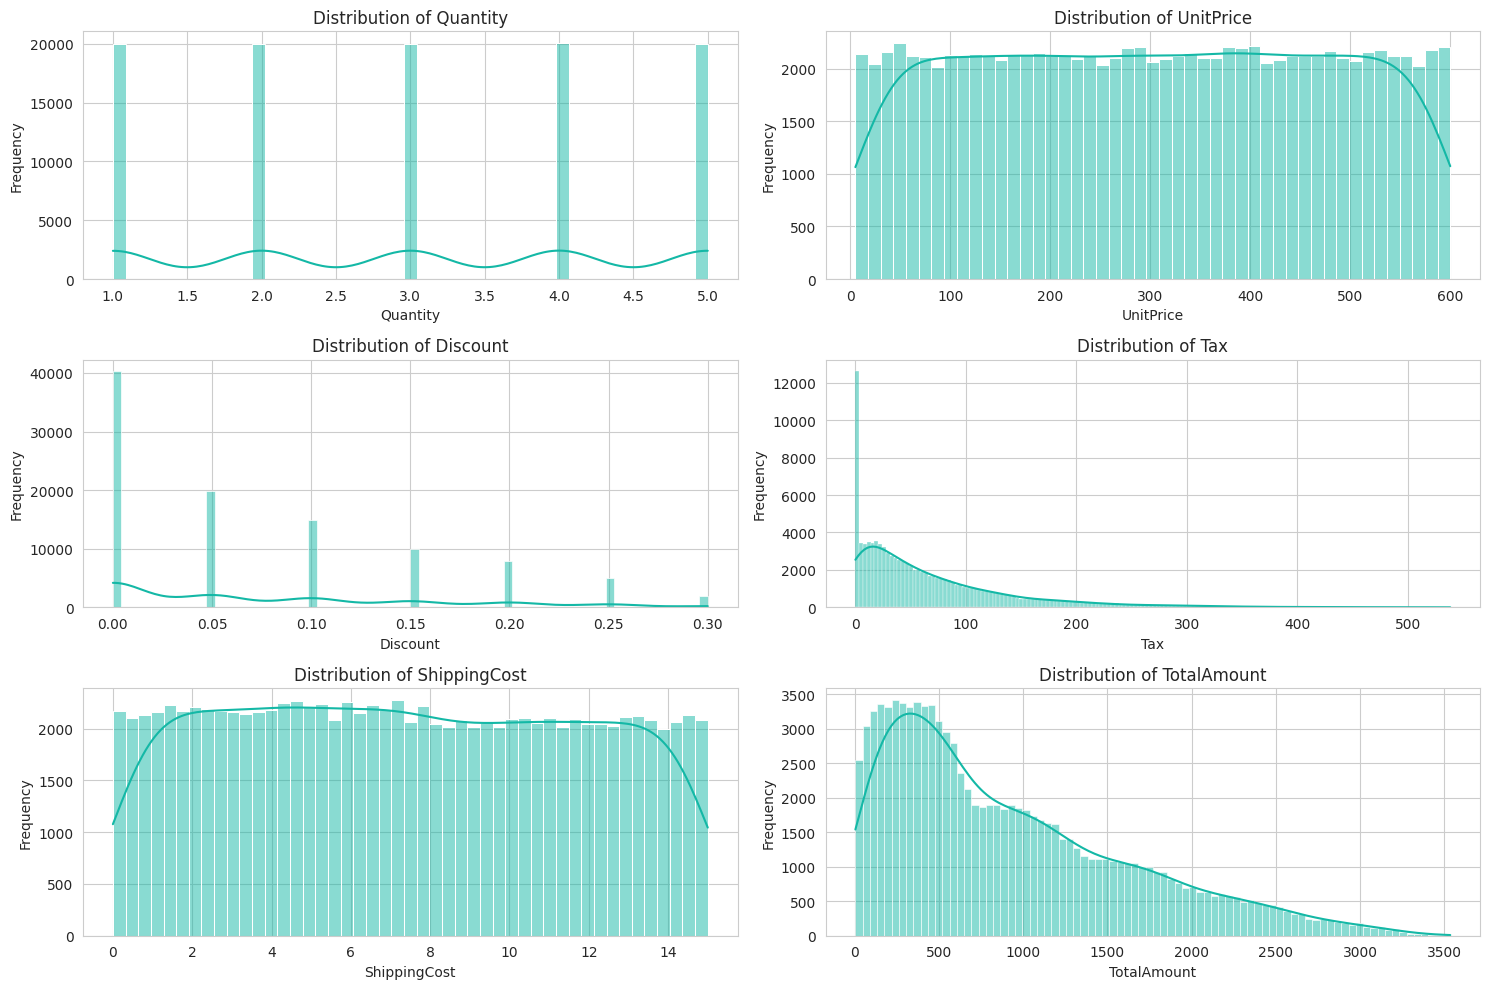

In [0]:
sns.set_style("whitegrid")

numeric_cols = pd_df.columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(pd_df[col], kde=True,kde_kws={'bw_adjust': 2},color="#14B8A6")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Outlier Detection Using Boxplots

Boxplots provide a compact visualization of the **spread and variability** of numerical features.

### What boxplots show

Each boxplot displays:

- Median (central line)
- Interquartile Range (IQR)
- Minimum and maximum values
- Potential outliers

### Why this matters

Detecting outliers is important because extreme values can:

- Distort statistical summaries
- Impact machine learning models
- Reveal unusual purchasing behavior

This analysis helps identify **orders with unusually high prices, quantities, or total values**.

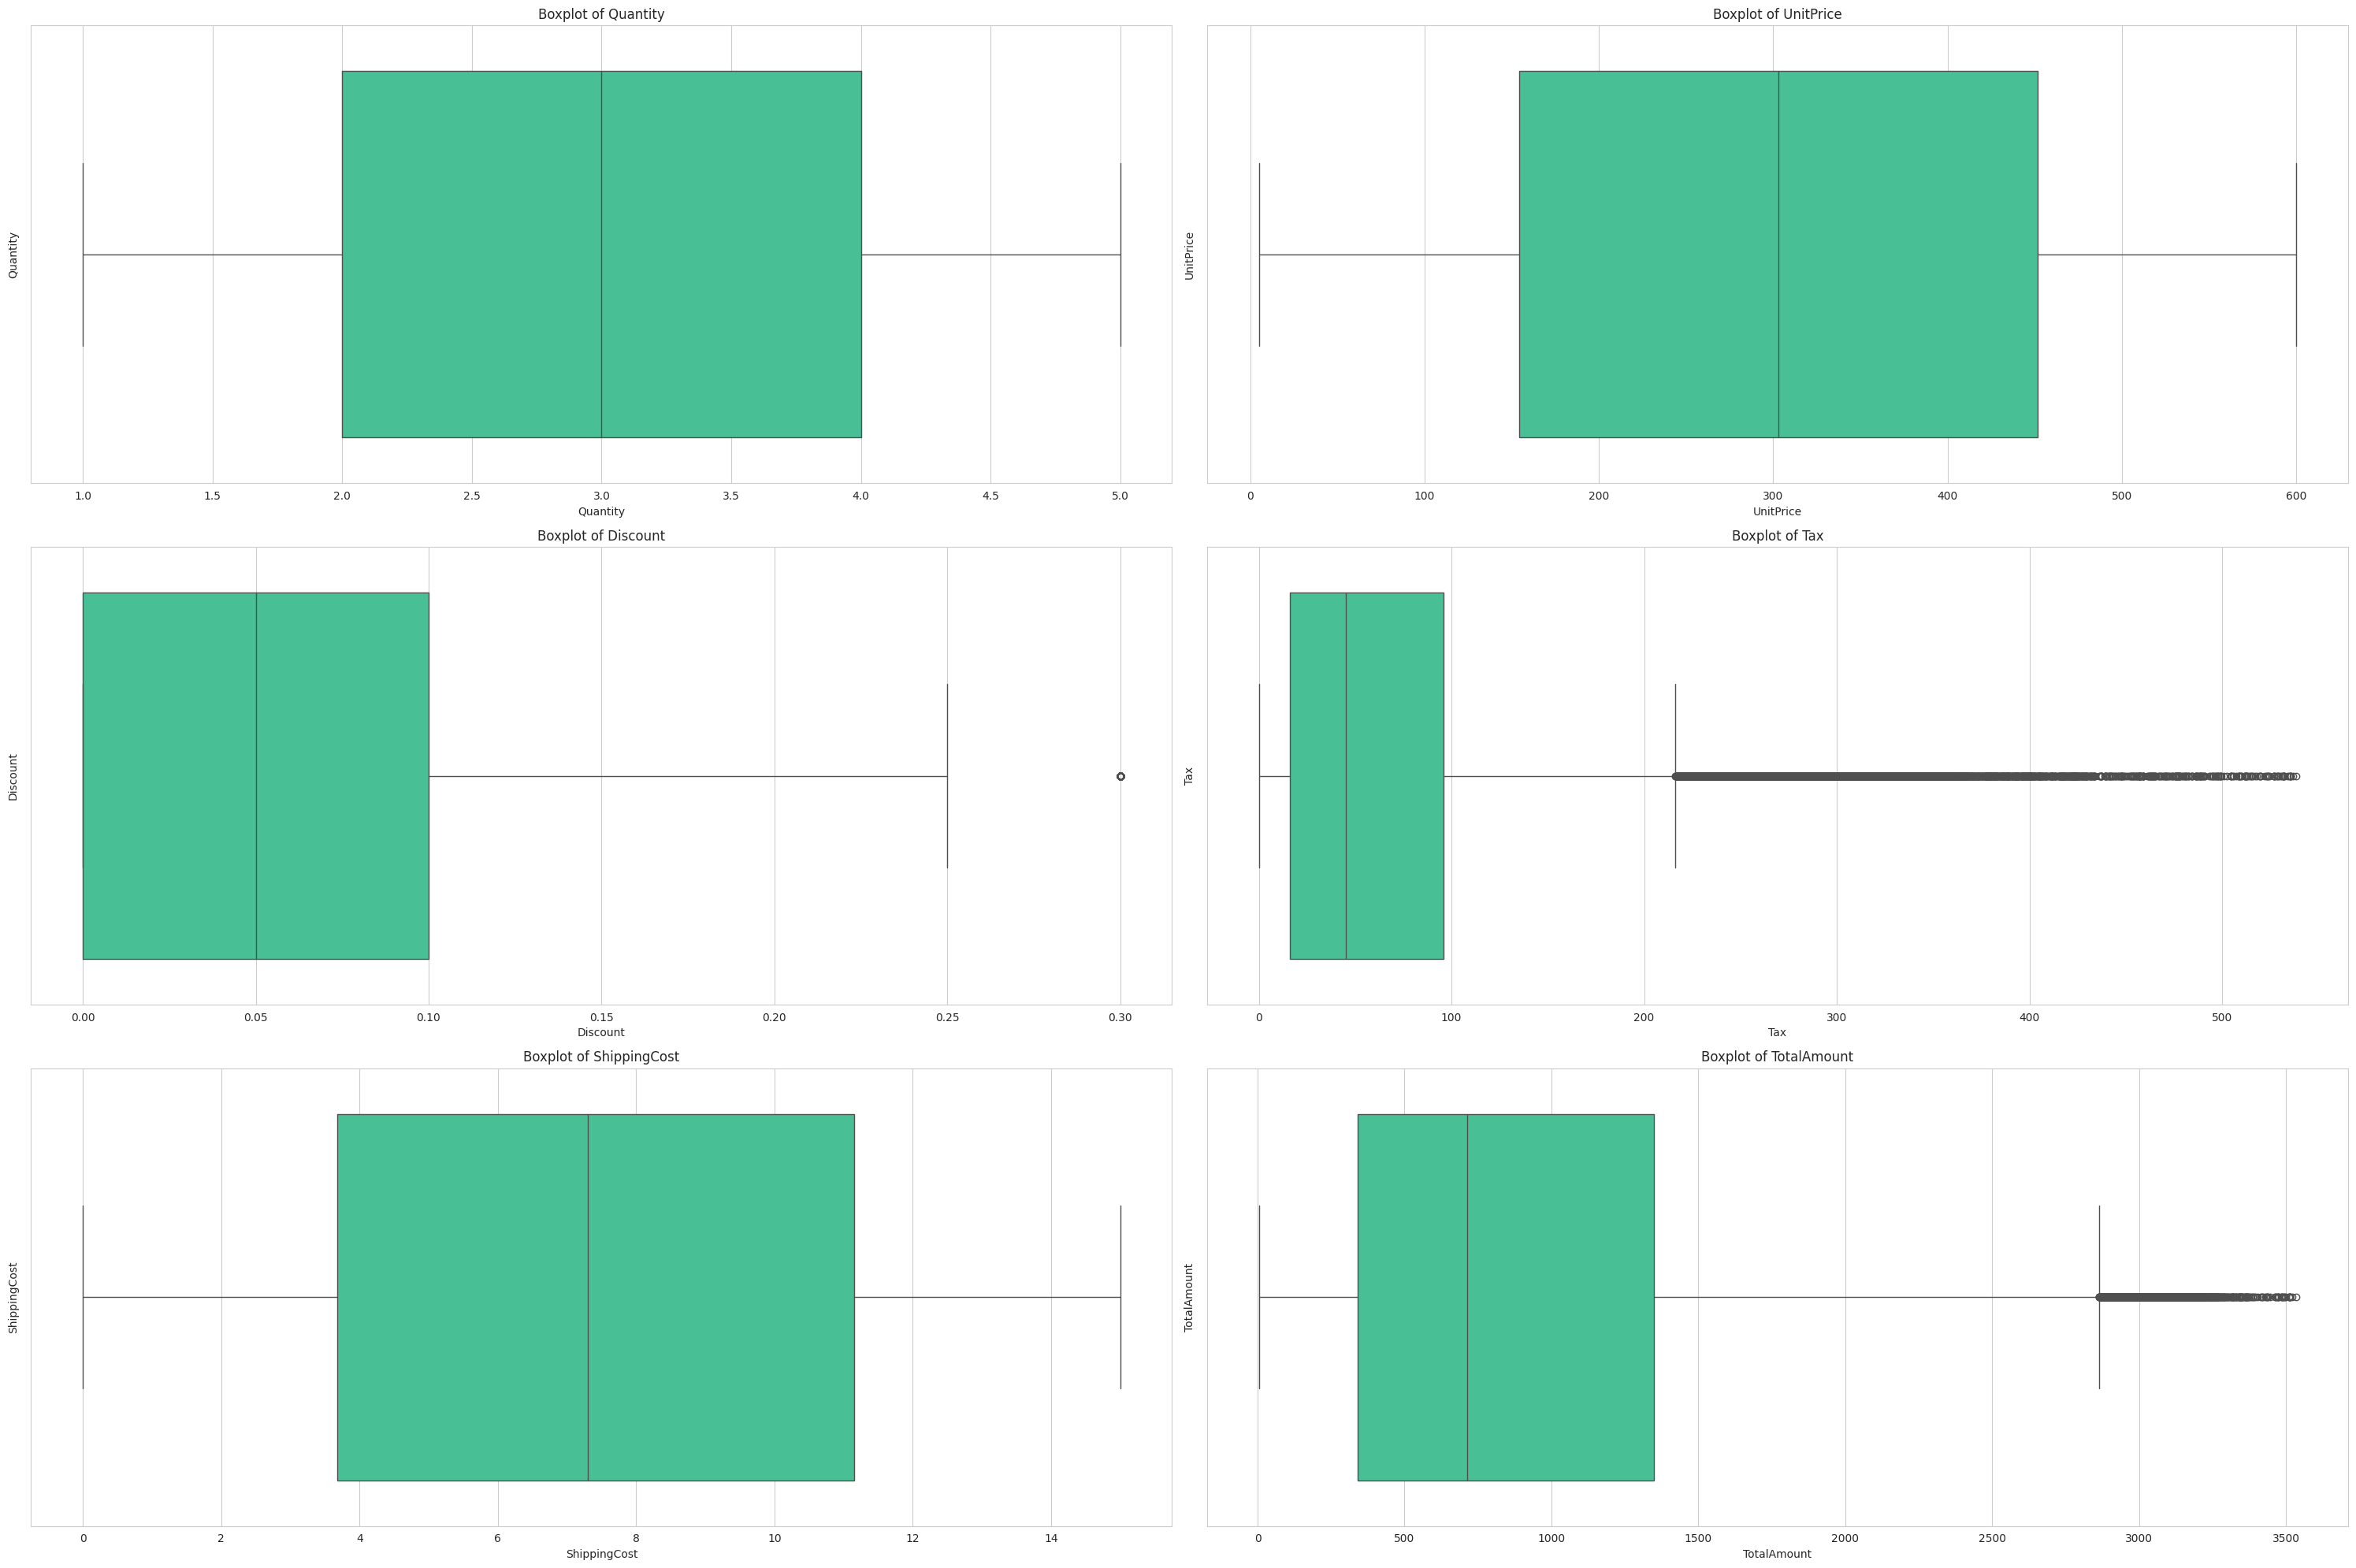

In [0]:
sns.set_style("whitegrid")

numeric_cols = pd_df.columns

plt.figure(figsize=(30, 20))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=pd_df[col],color="#34D399")   
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)

plt.tight_layout()
plt.show()


## Log-Scaled Distribution of Numerical Features

Many real-world commerce datasets contain **right-skewed distributions**, where most values are small but a few are extremely large.

To better visualize such patterns, we apply a **logarithmic scale to the x-axis**.

### Benefits of log scaling

- Compresses large values
- Makes skewed distributions easier to interpret
- Reveals hidden patterns in lower value ranges

This transformation helps us observe the **true spread of order values, prices, and quantities** without extreme values dominating the visualization.

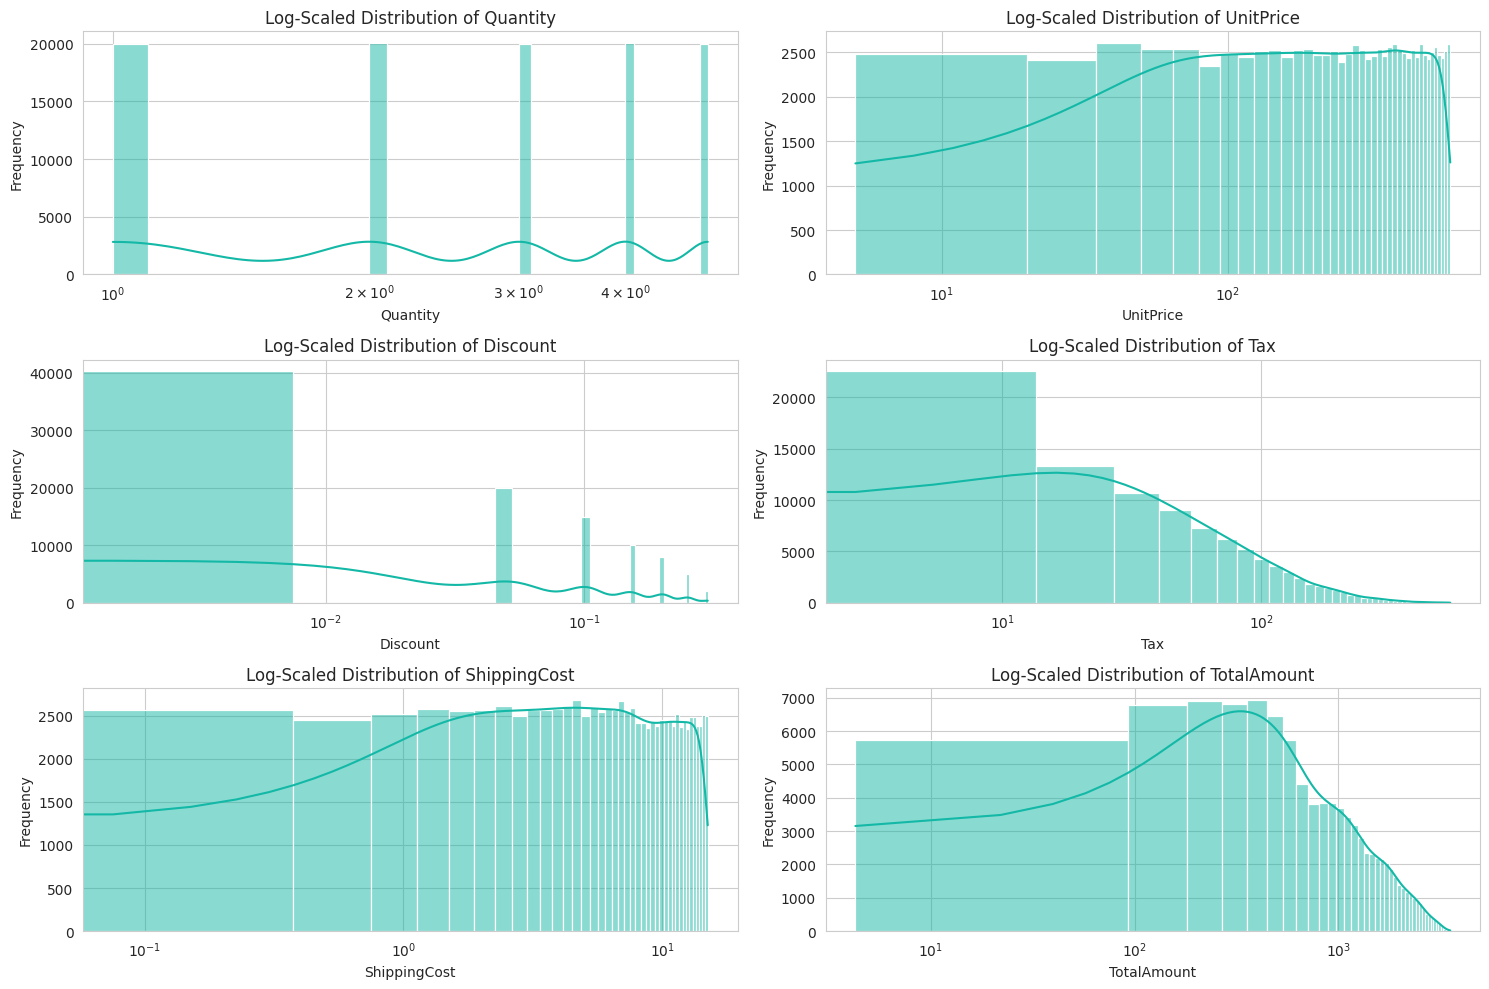

In [0]:
sns.set_style("whitegrid")

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(pd_df[col], kde=True, kde_kws={'bw_adjust': 2},bins=40,color="#14B8A6")
    plt.xscale("log")
    plt.title(f"Log-Scaled Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Correlation Analysis of Numerical Features

To understand relationships between numerical variables, we compute a **correlation matrix** and visualize it using a heatmap.

### What correlation shows

Correlation values range from **-1 to +1**:

- **+1** → strong positive relationship
- **0** → no relationship
- **-1** → strong negative relationship

### Purpose of this analysis

This helps identify:

- Features that strongly influence total order value
- Relationships between pricing and quantity
- Potential multicollinearity between variables

The heatmap allows us to quickly identify **strong associations between variables in the dataset**.

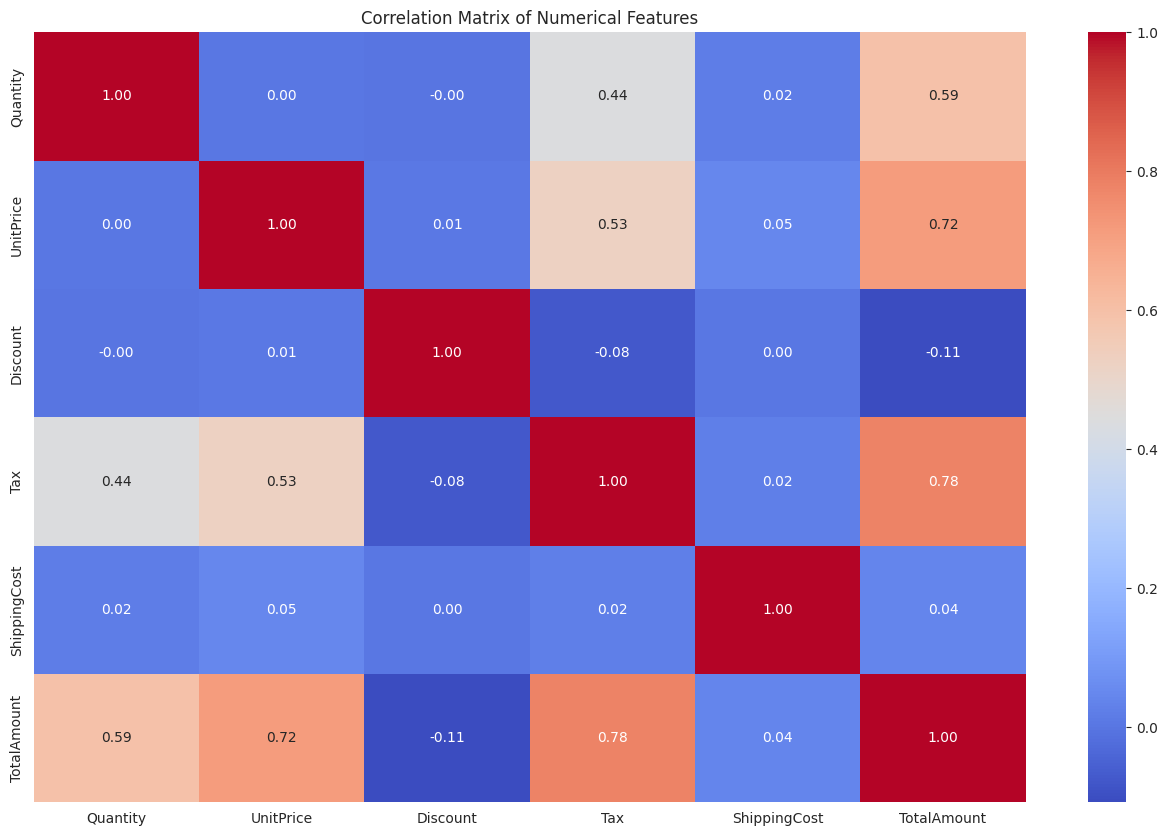

In [0]:
plt.figure(figsize=(16, 10))
sns.heatmap(pd_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()


### Key Observations

- Total Amount shows strong correlation with Quantity and Unit Price.
- Discount has a weaker correlation with Total Amount.
- Profit Proxy closely follows Total Amount, as expected.

These relationships confirm that order value is primarily driven by **price and quantity rather than discounts**.

## 📈 Sales Trends Over Time

## Time-Based Feature Engineering

To analyze sales trends over time, we extract temporal features from the `OrderDate` column.

### Steps performed
1. Convert the `OrderDate` string into a proper date format.
2. Extract the **year** of each order.
3. Extract the **quarter** of the year.

These features will allow us to analyze how revenue changes across different time periods.

In [0]:
df_time = (
    df
    .withColumn("OrderDateParsed", f.to_date("OrderDate", "dd-MM-yyyy"))
    .withColumn("OrderYear", f.year("OrderDateParsed"))
    .withColumn("Quarter", f.quarter("OrderDateParsed"))
)

df_time = df_time.withColumn(
    "YearQuarter",
    f.concat(
        f.lit("Q"),
        f.col("Quarter"),
        f.lit(" "),
        f.col("OrderYear")
    )
)
display(df_time.limit(10))

OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID,OrderDateParsed,OrderYear,Quarter,YearQuarter
ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,CREDIT CARD,Cancelled,San Antonio,Tx,CANADA,SELL01411,2023-02-04,2023,1,Q1 2023
ORD0000058,2024-02-17,CUST040925,Vivaan Verma,P00005,Laptop Sleeve,Clothing,UrbanStyle,5,182.55,0.0,45.64,12.08,970.47,UPI,Delivered,San Diego,Ca,CANADA,SELL01920,2024-02-17,2024,1,Q1 2024
ORD0000076,2022-08-13,CUST042061,Mohit Reddy,P00010,Smartwatch,Clothing,CoreTech,4,437.47,0.0,314.98,8.82,2073.68,CREDIT CARD,Shipped,Philadelphia,Pa,CANADA,SELL01119,2022-08-13,2022,3,Q3 2022
ORD0000125,2020-03-05,CUST009308,Vihaan Sharma,P00021,Backpack,Sports & Outdoors,HomeEase,5,200.05,0.05,114.03,2.34,1066.61,CREDIT CARD,Delivered,Houston,Tx,UNITED KINGDOM,SELL00770,2020-03-05,2020,1,Q1 2020
ORD0000147,2020-07-19,CUST037485,Kabir Verma,P00015,Instant Pot,Electronics,KiddoFun,1,194.17,0.0,9.71,5.33,209.21,CREDIT CARD,Delivered,San Francisco,Ca,INDIA,SELL01097,2020-07-19,2020,3,Q3 2020
ORD0000186,2022-10-17,CUST021204,Pooja Singh,P00042,Projector Mini,Toys & Games,UrbanStyle,2,495.32,0.0,49.53,10.01,1050.18,CREDIT CARD,Pending,Phoenix,Az,UNITED STATES,SELL01469,2022-10-17,2022,4,Q4 2022
ORD0000190,2023-12-01,CUST034016,Aditya Singh,P00046,Car Charger,Sports & Outdoors,Zenith,3,416.84,0.15,85.04,14.4,1162.38,DEBIT CARD,Delivered,Phoenix,Az,UNITED STATES,SELL01532,2023-12-01,2023,4,Q4 2023
ORD0000198,2023-03-29,CUST027565,Sneha Verma,P00019,LED Desk Lamp,Home & Kitchen,CoreTech,2,387.31,0.0,92.95,7.12,874.69,DEBIT CARD,Delivered,San Francisco,Ca,UNITED STATES,SELL01488,2023-03-29,2023,1,Q1 2023
ORD0000217,2024-03-09,CUST019363,Sunita Reddy,P00005,Laptop Sleeve,Toys & Games,FitLife,5,470.82,0.1,169.5,12.39,2300.58,DEBIT CARD,Delivered,Denver,Co,UNITED STATES,SELL01565,2024-03-09,2024,1,Q1 2024
ORD0000233,2024-01-19,CUST028877,Anjali Kapoor,P00005,Laptop Sleeve,Home & Kitchen,UrbanStyle,3,512.13,0.0,122.91,14.93,1674.23,NET BANKING,Delivered,Chicago,Il,UNITED STATES,SELL00809,2024-01-19,2024,1,Q1 2024


## Quarterly Revenue Aggregation

After extracting the time features, we aggregate the data to compute **total revenue per quarter**.

### Why quarterly analysis?

Quarterly trends help reveal:

- Seasonal purchasing patterns
- Growth or decline in revenue over time
- Periods of high customer activity

This aggregation groups all orders by **year and quarter** and calculates the total revenue generated during each period.

In [0]:
quarterly_sales = (
    df_time
    .groupBy("OrderYear", "Quarter", "YearQuarter")
    .agg(f.round(f.sum("TotalAmount"), 2).alias("QuarterlyRevenue"))
    .orderBy("OrderYear", "Quarter")
)

display(
    quarterly_sales.select("YearQuarter", "QuarterlyRevenue").limit(10)
)

YearQuarter,QuarterlyRevenue
Q1 2020,4563583.27
Q2 2020,4622450.75
Q3 2020,4748539.08
Q4 2020,4595290.92
Q1 2021,4484785.11
Q2 2021,4636125.35
Q3 2021,4676905.0
Q4 2021,4450759.35
Q1 2022,4569435.51
Q2 2022,4577172.31


In [0]:
def human_format(x, pos):
    if x >= 1_000_000_000:
        return f'{x/1_000_000_000:.1f}B'
    elif x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{x/1_000:.2f}K'
    else:
        return f'{x:.0f}'
    

## Quarterly Revenue Trend Visualization

To better understand revenue patterns over time, we visualize the **quarterly revenue trend** using a line chart.

### What this chart shows

- Revenue growth across quarters
- Possible seasonal peaks in sales
- Long-term performance trends

The y-axis values are formatted using a **human-readable format (K, M, B)** to improve readability for large revenue values.

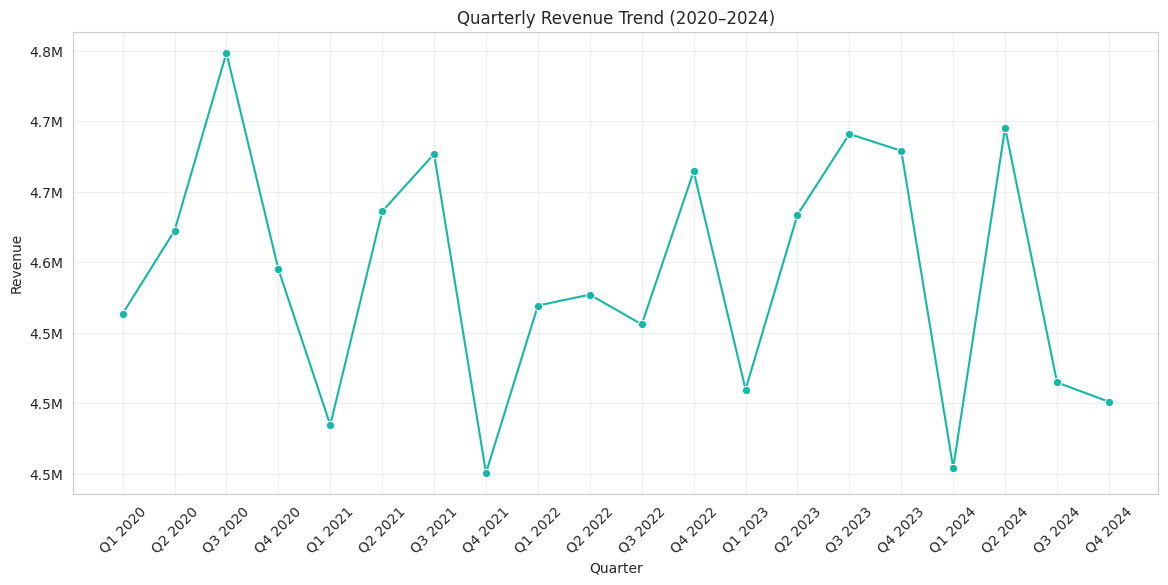

In [0]:
pdf_q = quarterly_sales.orderBy("OrderYear", "Quarter").toPandas()
plt.figure(figsize=(14,6))

sns.lineplot(
    data=pdf_q,
    x="YearQuarter",
    y="QuarterlyRevenue",
    marker="o",
    color="#14B8A6"
)

plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(human_format)
)

plt.title("Quarterly Revenue Trend (2020–2024)")
plt.xlabel("Quarter")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)

plt.show()

## 🛍️ Product & Category Performance

In this section, we analyze how different **product categories, products, and brands** contribute to overall sales performance.

Understanding product performance helps answer key business questions such as:

- Which product categories generate the most revenue?
- Which individual products sell the most units?
- Which brands drive the highest sales?

These insights can support **inventory planning, marketing strategies, and supplier decisions**.

### Category Revenue Contribution

This analysis examines how each product category contributes to overall business performance.

Metrics calculated per category:

- Total number of orders
- Total quantity sold
- Average quantity per order
- Average unit price
- Average order value
- Total revenue generated
- Percentage contribution to overall revenue

This helps identify **high-performing product categories** and understand which categories drive the majority of revenue.

In [0]:
total_revenue = df.agg(f.sum("TotalAmount")).collect()[0][0]

category_contribution = df.groupBy("Category").agg(
    f.count("OrderID").alias("TotalOrders"),
    f.sum("Quantity").alias("TotalQuantity"),
    f.round(f.avg("Quantity"), 2).alias("AvgQuantity"),
    f.round(f.avg("UnitPrice"), 2).alias("AvgPrice"),
    f.round(f.avg("TotalAmount"), 2).alias("AvgOrderValue"),
    f.round(f.sum("TotalAmount"), 2).alias("TotalRevenue")
).withColumn(
    "RevenuePercent",
    f.round((f.col("TotalRevenue") / total_revenue ) * 100, 2)
).orderBy(f.desc("TotalRevenue"))

category_contribution.display()

Category,TotalOrders,TotalQuantity,AvgQuantity,AvgPrice,AvgOrderValue,TotalRevenue,RevenuePercent
Electronics,16853,50696,3.01,302.93,924.71,1.558421718E7,16.97
Sports & Outdoors,16804,50543,3.01,301.76,913.21,1.534557188E7,16.71
Books,16752,49981,2.98,302.02,911.05,1.526183701E7,16.62
Clothing,16439,49523,3.01,305.2,927.88,1.52533975E7,16.61
Toys & Games,16542,49773,3.01,302.81,919.88,1.521668499E7,16.57
Home & Kitchen,16610,49624,2.99,302.76,912.94,1.516393936E7,16.51


### Revenue Contribution by Category

To understand the importance of each product category, we calculate the **percentage contribution of each category to total revenue**.

The donut chart below highlights how revenue is distributed across categories.

This analysis helps identify:

- Dominant categories driving the business
- Categories with lower revenue contribution
- Potential areas for expansion or optimization

<Figure size 1600x1000 with 0 Axes>

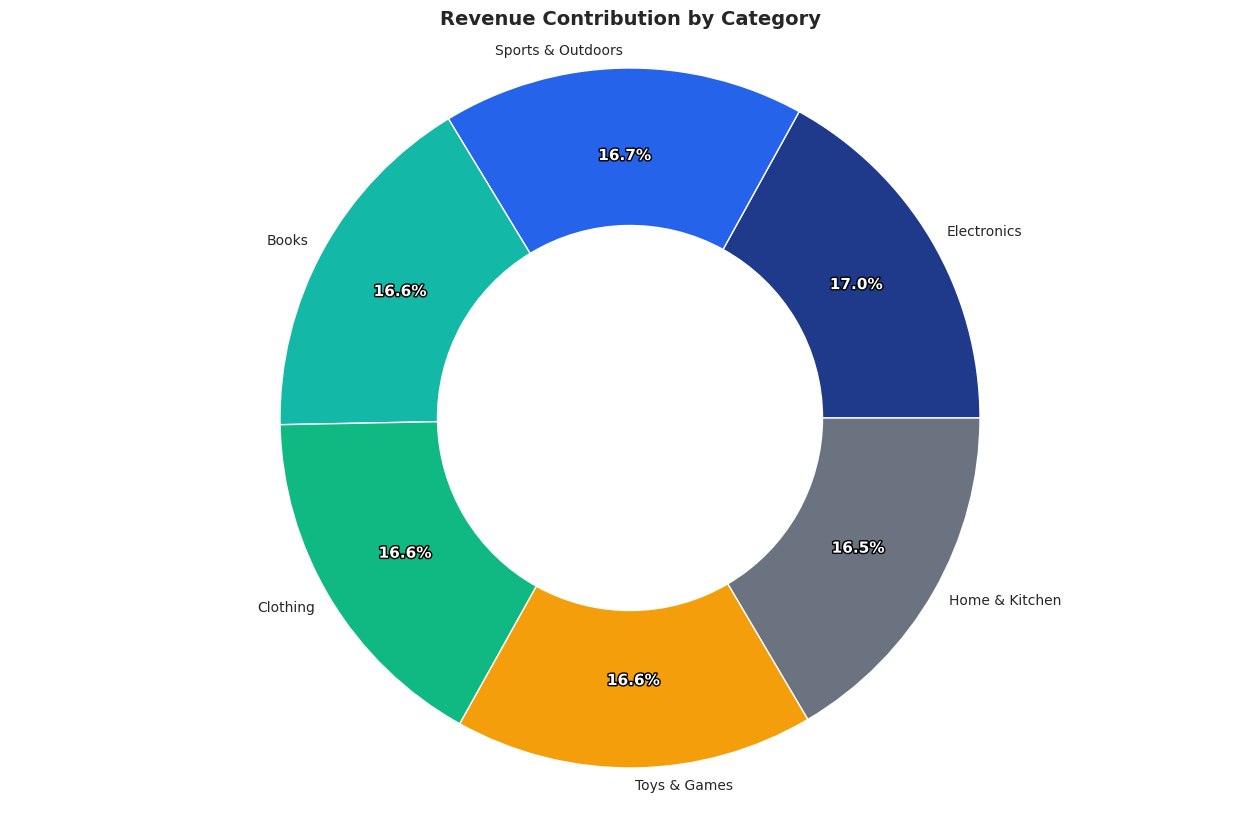

In [0]:
cat_contrib_pdf = category_contribution.select(
    "Category", "RevenuePercent"
).orderBy("RevenuePercent", ascending=False).toPandas()

plt.figure(figsize=(16,10))

custom_colors = [
    "#1F3A8A",  # Navy
    "#2563EB",  # Royal Blue
    "#14B8A6",  # Teal
    "#10B981",  # Emerald
    "#F59E0B",  # Amber
    "#6B7280"   # Soft Gray
]
plt.figure(figsize=(16,10))

wedges, texts, autotexts = plt.pie(
    cat_contrib_pdf["RevenuePercent"],
    labels=cat_contrib_pdf["Category"],
    autopct='%1.1f%%',
    startangle=0,
    colors=custom_colors,
    wedgeprops=dict(width=0.45),
    pctdistance=0.75,    
    labeldistance=1.05    

)

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(11)
    autotext.set_fontweight("bold")
    autotext.set_horizontalalignment("center")
    autotext.set_path_effects([
        path_effects.Stroke(linewidth=2, foreground='black'),
        path_effects.Normal()
    ])
    
plt.title("Revenue Contribution by Category", fontsize=14, fontweight='bold')
plt.axis("equal")
plt.show()

### Top 10 Products by Quantity Sold

Next, we identify the products with the **highest number of units sold**.

This metric highlights:

- The most frequently purchased products
- Customer demand patterns
- Products that require consistent inventory availability

High-quantity products are often **fast-moving items** that play an important role in maintaining steady sales volume.

In [0]:
top_products_qty = df.groupBy("ProductName") \
    .agg(f.sum("Quantity").alias("TotalQuantity")) \
    .orderBy("TotalQuantity", ascending=False) \
    .limit(10)

display(top_products_qty)

ProductName,TotalQuantity
LED Desk Lamp,6344
Water Bottle,6275
Memory Card 128GB,6240
Router,6202
Board Game,6200
Microphone,6196
Gaming Mouse,6170
Electric Kettle,6165
Mechanical Keyboard,6161
Vacuum Cleaner,6139


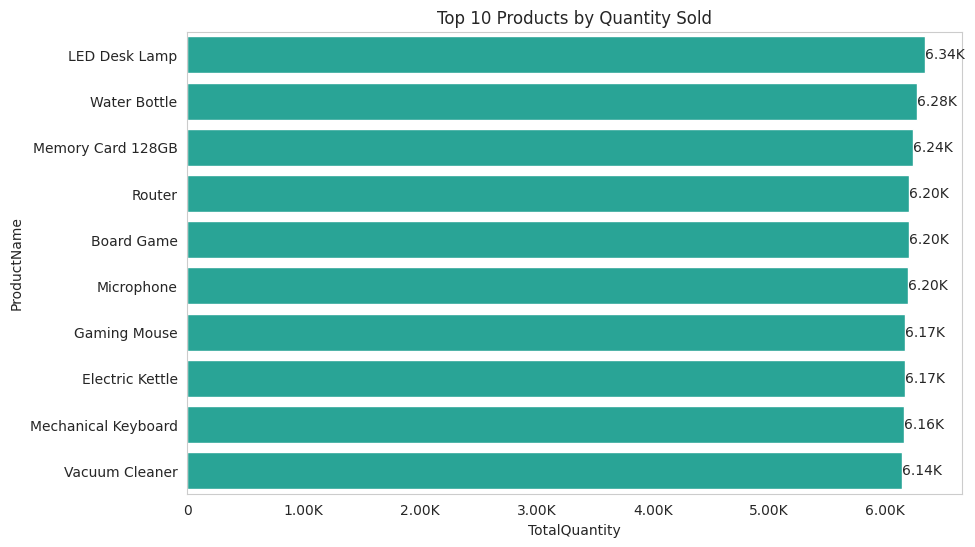

In [0]:
top_qty_pdf = top_products_qty.toPandas()

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top_qty_pdf, 
    x="TotalQuantity", 
    y="ProductName",
    color="#14B8A6"
    )

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(human_format)
)

for i, v in enumerate(top_qty_pdf["TotalQuantity"]):
    ax.text(
        v,                 
        i,                 
        f"{human_format(v, None)}",
        va="center"
    )

plt.title("Top 10 Products by Quantity Sold")
plt.grid(False)
plt.show()

### Top 10 Products by Revenue

While some products sell large quantities, others generate high revenue due to **higher unit prices**.

This analysis identifies the products that contribute the most to **overall revenue**, helping us understand:

- High-value products
- Premium product segments
- Key revenue drivers

In [0]:
top_products_revenue = df.groupBy("ProductName") \
    .agg(f.round(f.sum("TotalAmount"),2).alias("TotalRevenue")) \
    .orderBy("TotalRevenue", ascending=False) \
    .limit(10)

display(top_products_revenue)

ProductName,TotalRevenue
Memory Card 128GB,1935138.4
LED Desk Lamp,1921948.41
Mechanical Keyboard,1906963.54
Electric Kettle,1905751.79
Smartwatch,1901275.59
Dress Shirt,1896765.36
Water Bottle,1895467.95
Gaming Mouse,1895103.98
Kids Toy Car,1891082.43
Jeans,1882591.82


### Brand Performance Analysis

Brands play a major role in influencing customer purchasing behavior.

We evaluate brand performance using two key metrics:

- **Total Revenue Generated**
- **Total Quantity Sold**

This helps identify brands that dominate the marketplace and contribute significantly to overall sales.

In [0]:
brand_performance = df.groupBy("Brand") \
    .agg(
        f.round( f.sum("TotalAmount"),2).alias("TotalRevenue"),
        f.sum("Quantity").alias("TotalQuantity")
    ) \
    .orderBy("TotalRevenue", ascending=False)

display(brand_performance)

Brand,TotalRevenue,TotalQuantity
CoreTech,9343720.59,30430
KiddoFun,9324749.55,30168
ReadMore,9278406.63,30421
UrbanStyle,9249027.45,30104
Zenith,9239960.39,30058
Apex,9147604.72,29955
NexPro,9078824.97,29791
FitLife,9061444.68,30121
BrightLux,9056816.11,29616
HomeEase,9045092.83,29476


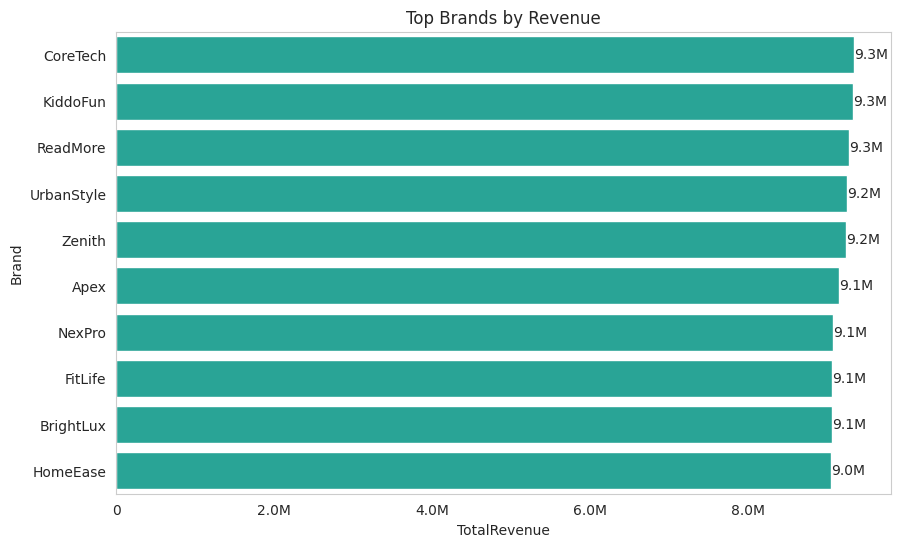

In [0]:
brand_pdf = brand_performance.limit(10).toPandas()

plt.figure(figsize=(10,6))
ax=sns.barplot(
    data=brand_pdf, 
    x="TotalRevenue", 
    y="Brand",
    color="#14B8A6"
    )

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(human_format)
)

for i, v in enumerate(brand_pdf["TotalRevenue"]):
    ax.text(
        v,                 
        i,                 
        f"{human_format(v, None)}",
        va="center"
    )
plt.title("Top Brands by Revenue")
plt.grid(False)
plt.show()

## 👥 Customer Behavior Analysis

Understanding customer purchasing behavior is essential for identifying valuable customers and improving retention strategies.

In this section, we analyze customer-level metrics including:

- Total number of orders placed
- Total amount spent
- Average order value per customer

These metrics help identify **high-value customers**, spending patterns, and potential repeat buyers.

### Customer-Level Metrics

We calculate key metrics for each customer:

- **TotalOrders** – number of purchases made by the customer  
- **TotalSpend** – total revenue generated by the customer  
- **AvgOrderValue** – average value of each order

Sorting customers by **TotalSpend and TotalOrders** helps identify the most valuable customers in the dataset.

In [0]:
customer_metrics = df.groupBy("CustomerID") \
    .agg(
        f.count("OrderID").alias("TotalOrders"),
        f.round(f.sum("TotalAmount"),2).alias("TotalSpend"),
        f.round(f.avg("TotalAmount"),2).alias("AvgOrderValue")
    )\
        .orderBy("TotalSpend","TotalOrders", ascending=[False,False])

display(customer_metrics.limit(10))

CustomerID,TotalOrders,TotalSpend,AvgOrderValue
CUST023748,10,15215.79,1521.58
CUST009614,9,12160.96,1351.22
CUST034178,6,11418.88,1903.15
CUST001153,9,11282.96,1253.66
CUST004883,5,11214.44,2242.89
CUST000787,7,10962.32,1566.05
CUST015677,5,10956.1,2191.22
CUST042689,8,10726.8,1340.85
CUST015231,6,10638.79,1773.13
CUST033270,5,10593.41,2118.68


### Top Customers by Total Spend

The chart below highlights customers who contribute the highest revenue.

Identifying top-spending customers helps businesses:

- Recognize high-value buyers
- Design loyalty or reward programs
- Focus marketing efforts on profitable customer segments

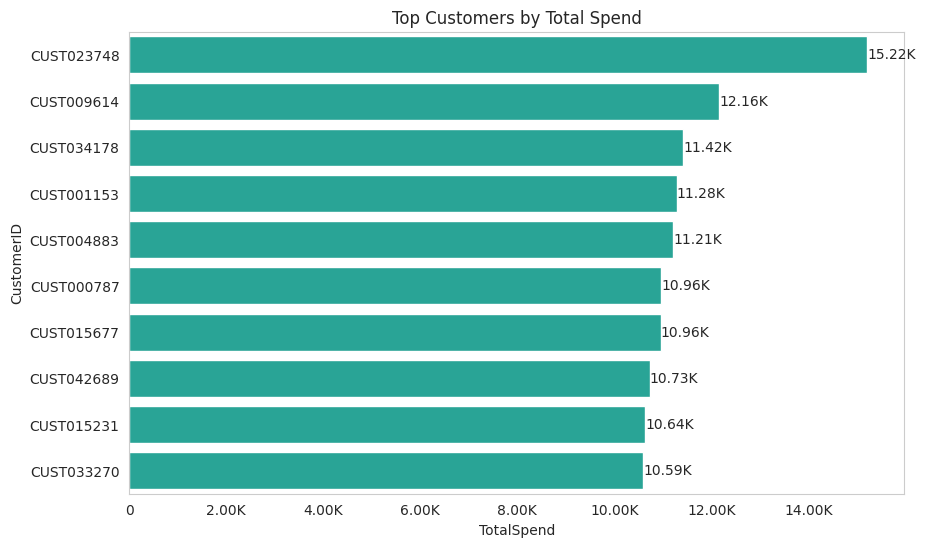

In [0]:
customer_metrics_pdf = customer_metrics.limit(10).toPandas()

plt.figure(figsize=(10,6))
ax=sns.barplot(
    data=customer_metrics_pdf, 
    x="TotalSpend", 
    y="CustomerID",
    color="#14B8A6"
    )

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(human_format)
) 

for i, v in enumerate(customer_metrics_pdf["TotalSpend"]):
    ax.text(
        v,                 
        i,                 
        f"{human_format(v, None)}",
        va="center"
    )

plt.title("Top Customers by Total Spend") 
plt.grid(False)
plt.show()

### Repeat Customer Analysis

Customer retention is a key indicator of business health.

We classify customers into two groups:

- **Repeat Customers** – customers who placed more than one order  
- **One-Time Customers** – customers who placed only one order  

This helps evaluate the proportion of returning customers and overall customer loyalty.

In [0]:
repeat_analysis = customer_metrics.withColumn(
    "CustomerType",
    f.when(f.col("TotalOrders") > 1, "Repeat Customer")
     .otherwise("One-Time Customer")
)

display(repeat_analysis.groupBy("CustomerType").count())

CustomerType,count
One-Time Customer,13532
Repeat Customer,29701


## 🌍 Geographic Insights

Geographic analysis helps understand how sales are distributed across different regions.

In this section, we examine:

- Revenue contribution by country
- Order volume by region
- Revenue distribution within states of each country

These insights can support **regional marketing strategies, logistics planning, and market expansion decisions**.

### Revenue Distribution by Country

We aggregate sales data at the **country level** to evaluate regional performance.

Key metrics calculated:

- Total Revenue
- Total Quantity Sold
- Total Orders
- Average Order Value

This analysis helps identify the countries that contribute the most to overall business revenue.

In [0]:
geo_country = df.groupBy("Country") \
                .agg(
                    f.round(f.sum("TotalAmount"),2).alias("TotalRevenue"),
                    f.sum("Quantity").alias("TotalQuantity"),
                    f.count("OrderID").alias("TotalOrders"),
                    f.round( f.avg("TotalAmount"),2).alias("AvgOrderValue")
                ) \
                .orderBy("TotalRevenue", ascending=False)

geo_country = geo_country.withColumn(
    "RevenuePercent",
    f.round(f.col("TotalRevenue") / total_revenue * 100,2)
)

display(geo_country)

Country,TotalRevenue,TotalQuantity,TotalOrders,AvgOrderValue,RevenuePercent
UNITED STATES,6.43100485E7,210409,70058,917.95,70.03
INDIA,1.387583912E7,45082,15051,921.92,15.11
CANADA,5323757.0,17381,5818,915.05,5.8
UNITED KINGDOM,4526896.86,14831,4943,915.82,4.93
AUSTRALIA,3789106.44,12437,4130,917.46,4.13


### Country Revenue Contribution

The donut chart below shows the **percentage share of total revenue generated by each country**.

This visualization highlights:

- Dominant markets
- Regions with strong demand
- Potential opportunities for geographic expansion

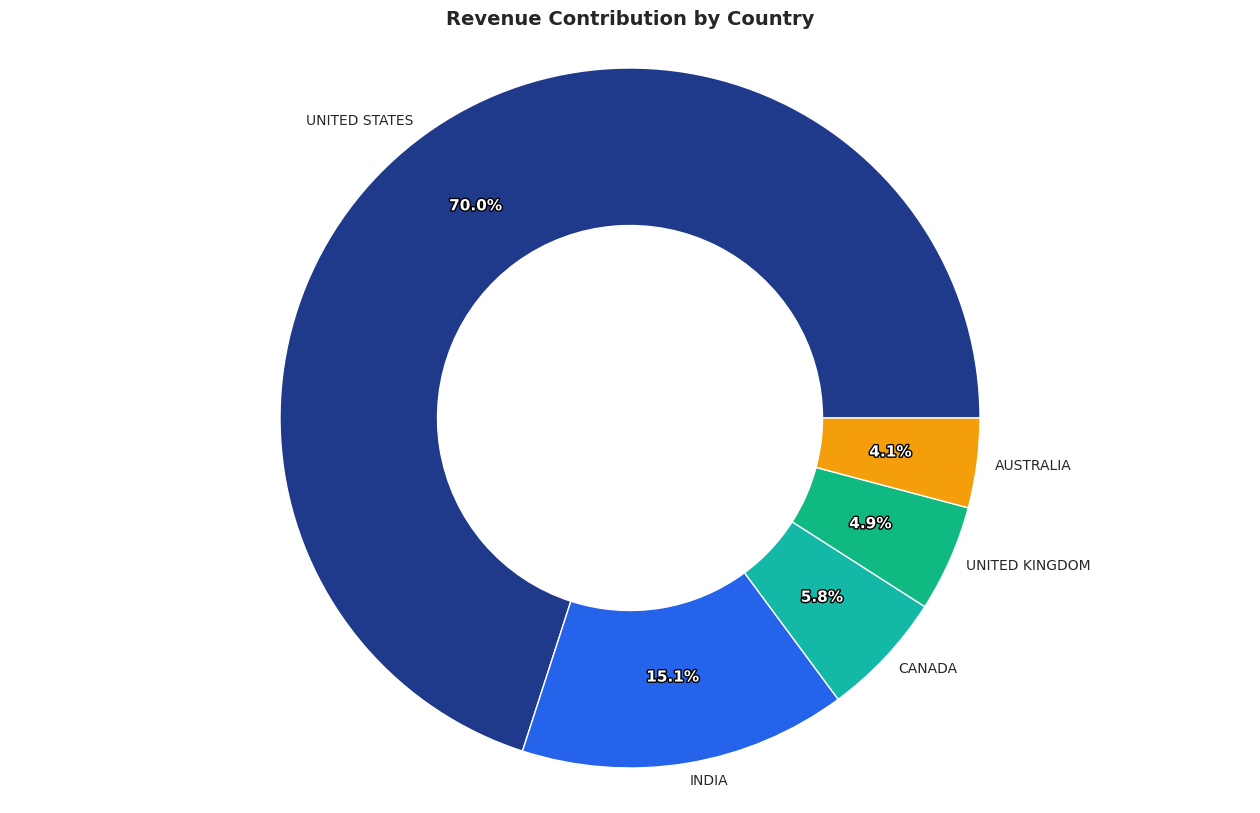

In [0]:
geo_country_pdf = geo_country.select(
    "Country", "RevenuePercent"
).orderBy("RevenuePercent", ascending=False).toPandas()

plt.figure(figsize=(16,10))

custom_colors = [
    "#1F3A8A",  # Navy
    "#2563EB",  # Royal Blue
    "#14B8A6",  # Teal
    "#10B981",  # Emerald
    "#F59E0B",  # Amber
    "#6B7280"   # Soft Gray
]

wedges, texts, autotexts = plt.pie(
    geo_country_pdf["RevenuePercent"],
    labels=geo_country_pdf["Country"],
    autopct='%1.1f%%',
    startangle=0,
    colors=custom_colors,
    wedgeprops=dict(width=0.45),
    pctdistance=0.75,    
    labeldistance=1.05    

)

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(11)
    autotext.set_fontweight("bold")
    autotext.set_horizontalalignment("center")
    autotext.set_path_effects([
        path_effects.Stroke(linewidth=2, foreground='black'),
        path_effects.Normal()
    ])
    
plt.title("Revenue Contribution by Country", fontsize=14, fontweight='bold')
plt.axis("equal")
plt.show()

### Revenue Distribution by State

To gain deeper insights within each country, we analyze revenue distribution at the **state level**.

This allows us to identify:

- Top-performing states within each country
- Regional demand patterns
- Areas with strong market penetration

In [0]:
geo_state_country = df.groupBy("Country","State") \
              .agg(
                  f.round(f.sum("TotalAmount"),2).alias("TotalRevenue"),
                  f.count("OrderID").alias("TotalOrders")
              ) \
              .orderBy("Country","TotalRevenue", ascending=False)

display(geo_state_country)

Country,State,TotalRevenue,TotalOrders
UNITED STATES,Tx,1.589748853E7,17334
UNITED STATES,Ca,1.278366294E7,14014
UNITED STATES,Nc,3311877.73,3606
UNITED STATES,Pa,3287459.93,3543
UNITED STATES,Fl,3281693.36,3594
UNITED STATES,Il,3268618.39,3507
UNITED STATES,In,3246583.55,3469
UNITED STATES,Co,3240143.04,3462
UNITED STATES,Oh,3237947.84,3521
UNITED STATES,Wa,3224396.33,3504


### State Revenue Distribution Visualization

The charts below show the **top revenue-generating states for each country**.

Each donut chart represents a country, with slices showing the percentage revenue contribution of its leading states.

This helps identify **regional sales hotspots** within each market.

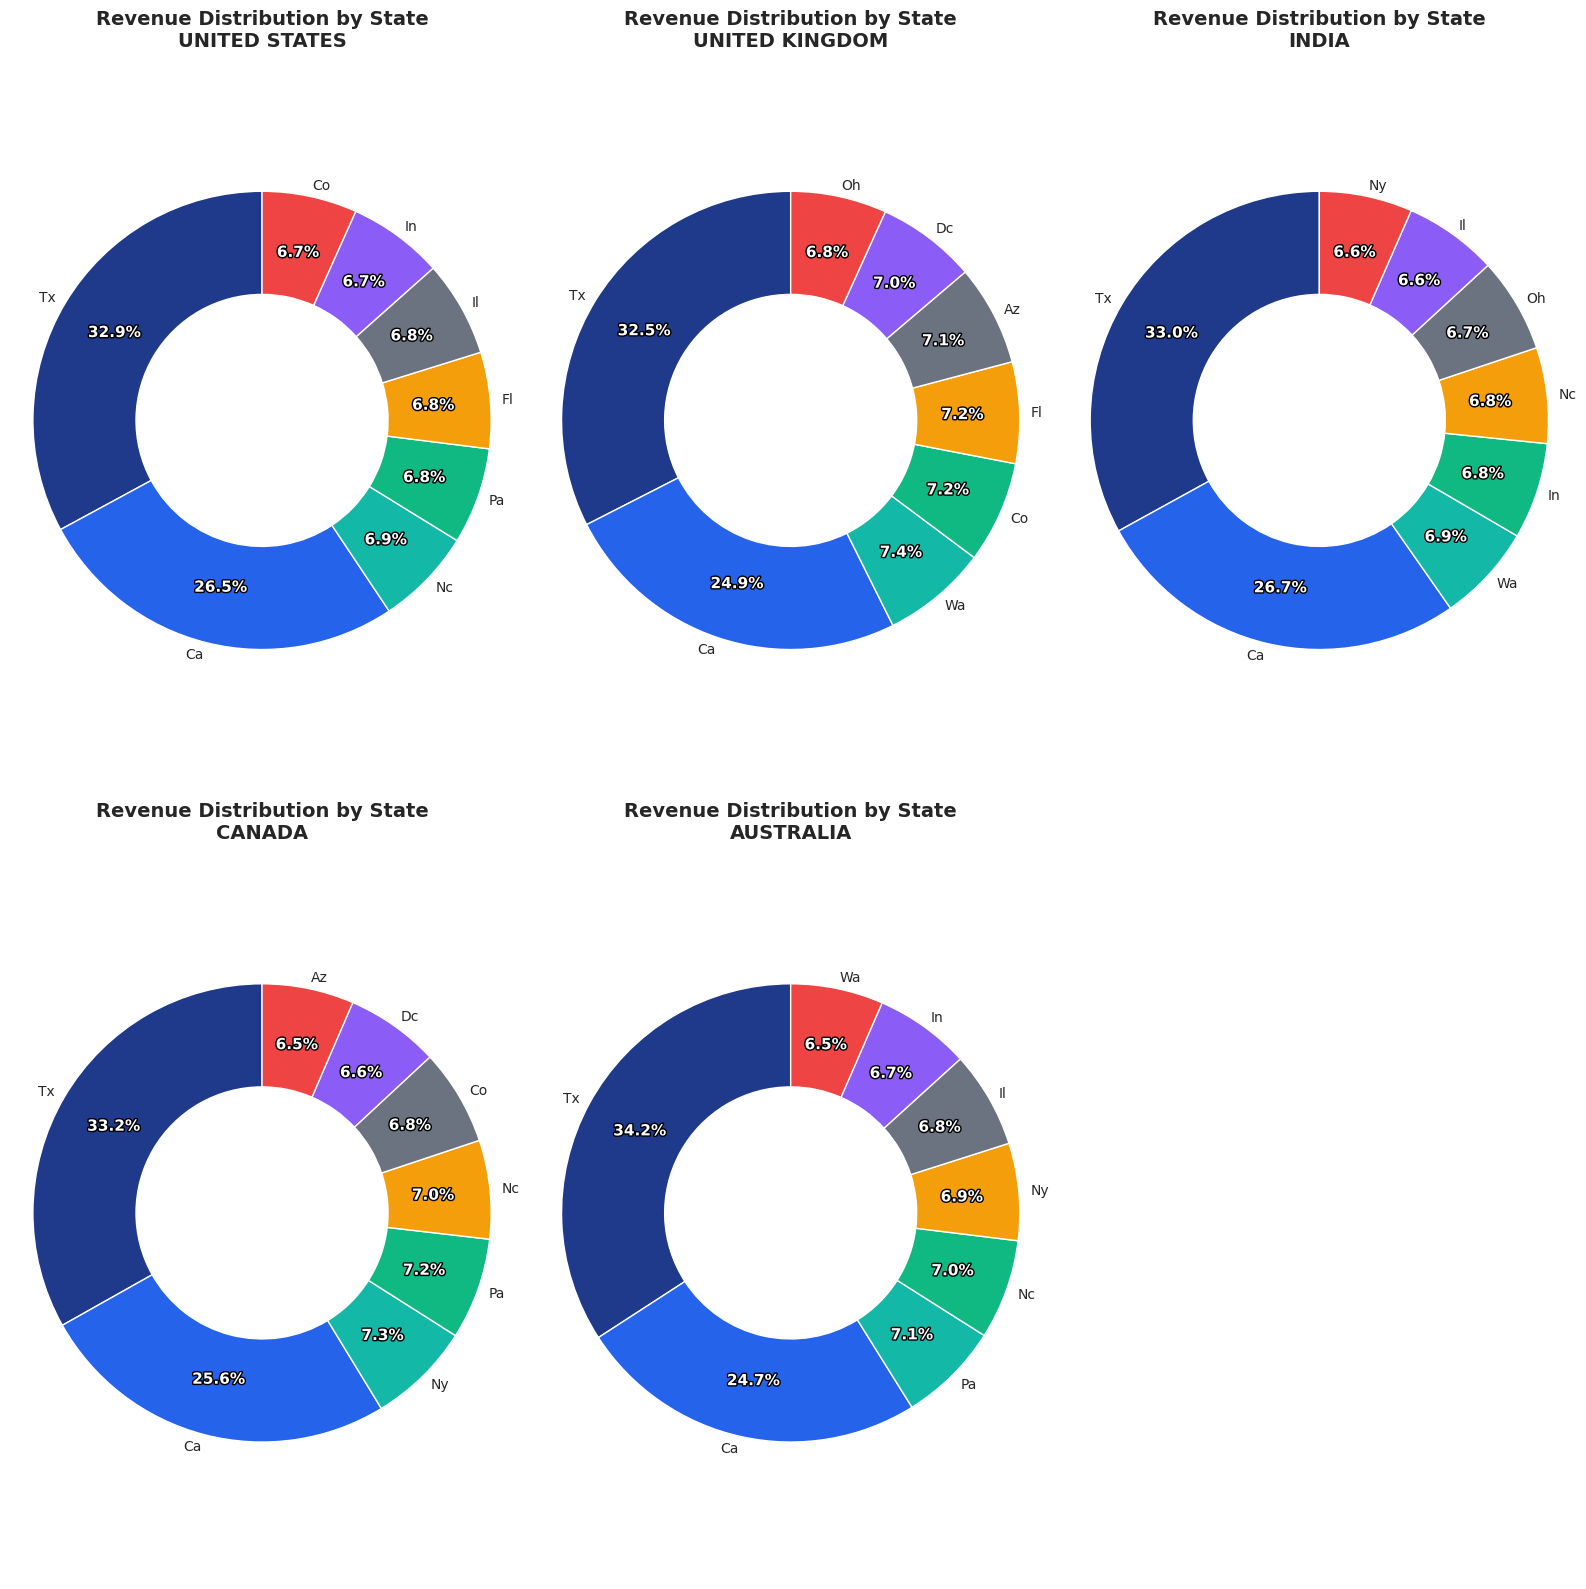

In [0]:
geo_pdf = geo_state_country.select("Country","State","TotalRevenue").toPandas()

countries = geo_pdf["Country"].unique()
num_countries = len(countries)

cols =3
rows = int(np.ceil(num_countries / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, 8 * rows))
axes = axes.flatten()

custom_colors = [
    "#1F3A8A",  # Navy
    "#2563EB",  # Royal Blue
    "#14B8A6",  # Teal
    "#10B981",  # Emerald
    "#F59E0B",  # Amber
    "#6B7280",  # Soft Gray
    "#8B5CF6",  # Violet
    "#EF4444"   # Red
]

for ax, country in zip(axes, countries):

    country_data = geo_pdf[geo_pdf["Country"] == country] \
        .sort_values(by="TotalRevenue", ascending=False) \
        .head(8)

    colors = custom_colors[:len(country_data)]

    wedges, texts, autotexts = ax.pie(
        country_data["TotalRevenue"],
        labels=country_data["State"],
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
        wedgeprops=dict(width=0.45),
        pctdistance=0.75,
        labeldistance=1.05
    )

    for autotext in autotexts:
        autotext.set_color("white")
        autotext.set_fontsize(11)
        autotext.set_fontweight("bold")
        autotext.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='black'),
            path_effects.Normal()
        ])

    ax.set_title(
        f"Revenue Distribution by State\n{country}",
        fontsize=14,
        fontweight="bold"
    )

    ax.axis("equal")

for i in range(len(countries), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

### Key Insights

- A small group of customers contribute a significant share of total revenue, highlighting the importance of **high-value customers**.
- Repeat customers play a crucial role in sustaining long-term sales.
- Revenue distribution varies across countries, indicating **regional differences in market demand**.
- Within each country, a few states generate the majority of revenue, revealing potential **sales concentration in specific regions**.

These findings can support decisions related to:

- customer loyalty programs
- targeted marketing campaigns
- regional business expansion strategies

## 💳 Payment & Order Status Analysis

Payment methods and order statuses provide valuable insights into customer behavior and operational efficiency.

In this section, we analyze:

- Revenue contribution by payment method
- Distribution of orders across payment types
- Revenue share by order status
- Overall delivery success rate

These insights help businesses understand **customer payment preferences** and evaluate the **efficiency of order fulfillment operations**.

### Payment Method Performance

We analyze how different payment methods contribute to total revenue.

For each payment method, we calculate:

- Total Revenue generated
- Total Quantity of items sold
- Total Number of Orders
- Average Order Value

This helps identify the most commonly used payment methods and their contribution to overall business performance.

In [0]:
payment_dist = df.groupBy("PaymentMethod") \
                .agg(
                      f.round(f.sum("TotalAmount"),2).alias("TotalRevenue"),
                      f.sum("Quantity").alias("TotalQuantity"),
                      f.count("OrderID").alias("TotalOrders"),
                      f.round(f.avg("TotalAmount"),2).alias("AvgOrderValue")
                  )\
                 .orderBy("TotalRevenue", ascending=False)

payment_dist = payment_dist.withColumn(
    "RevenuePercent",
    f.round(f.col("TotalRevenue") / total_revenue * 100,2)
)
display(payment_dist)

PaymentMethod,TotalRevenue,TotalQuantity,TotalOrders,AvgOrderValue,RevenuePercent
CREDIT CARD,3.212215869E7,105046,35038,916.78,34.98
DEBIT CARD,1.853867853E7,60242,20024,925.82,20.19
UPI,1.389602855E7,45218,15066,922.34,15.13
AMAZON PAY,1.369749842E7,45099,15017,912.13,14.92
NET BANKING,9055674.57,29699,9927,912.23,9.86
CASH ON DELIVERY,4515609.16,14836,4928,916.32,4.92


### Revenue Contribution by Payment Method

The donut chart below shows the **percentage share of revenue generated by each payment method**.

Understanding payment preferences helps businesses:

- Optimize checkout experiences
- Promote preferred payment options
- Design payment-based promotional campaigns

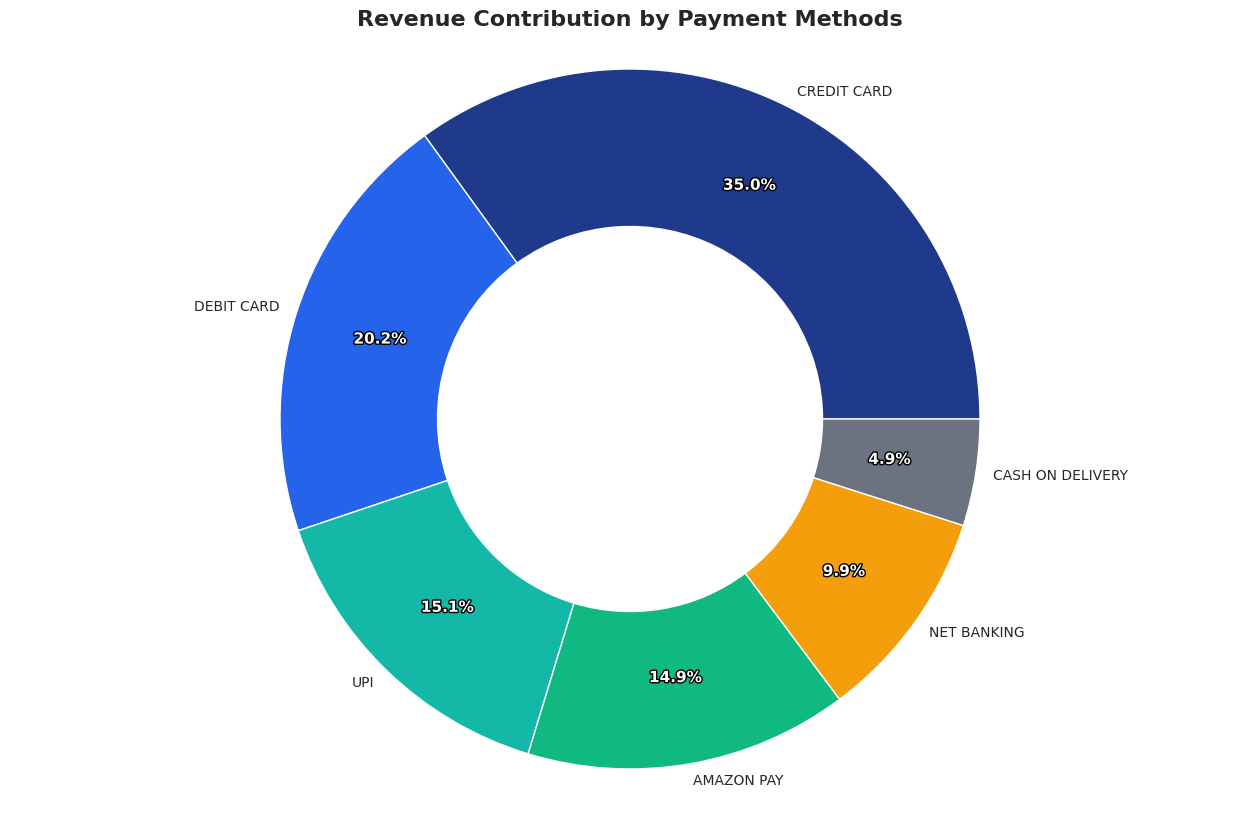

In [0]:
payment_dist_pdf = payment_dist.select(
    "PaymentMethod", "RevenuePercent"
).orderBy("RevenuePercent", ascending=False).toPandas()

plt.figure(figsize=(16,10))

custom_colors = [
    "#1F3A8A",  # Navy
    "#2563EB",  # Royal Blue
    "#14B8A6",  # Teal
    "#10B981",  # Emerald
    "#F59E0B",  # Amber
    "#6B7280"   # Soft Gray
]

wedges, texts, autotexts = plt.pie(
    payment_dist_pdf["RevenuePercent"],
    labels=payment_dist_pdf["PaymentMethod"],
    autopct='%1.1f%%',
    startangle=0,
    colors=custom_colors,
    wedgeprops=dict(width=0.45),
    pctdistance=0.75,    
    labeldistance=1.05    

)

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(11)
    autotext.set_fontweight("bold")
    autotext.set_horizontalalignment("center")
    autotext.set_path_effects([
        path_effects.Stroke(linewidth=2, foreground='black'),
        path_effects.Normal()
    ])
    
plt.title("Revenue Contribution by Payment Methods", fontsize=16, fontweight='bold')
plt.axis("equal")
plt.show()

### Order Status Performance

Order status analysis provides insights into the operational health of the order fulfillment process.

We evaluate how revenue and order counts are distributed across different order statuses, including:

- Delivered
- Shipped
- Pending
- Cancelled
- Returned

This analysis helps assess **order completion rates and potential operational issues**.

In [0]:
order_status_dist = df.groupBy("OrderStatus") \
    .agg(
        f.round(f.sum("TotalAmount"), 2).alias("TotalRevenue"),
        f.sum("Quantity").alias("TotalQuantity"),
        f.count("OrderID").alias("TotalOrders"),
        f.round(f.avg("TotalAmount"), 2).alias("AvgOrderValue")
    ) \
    .orderBy("TotalRevenue", ascending=False)

order_status_dist = order_status_dist.withColumn(
    "RevenuePercent",
    f.round((f.col("TotalRevenue") / total_revenue) * 100, 2)
)

display(order_status_dist)

OrderStatus,TotalRevenue,TotalQuantity,TotalOrders,AvgOrderValue,RevenuePercent
Delivered,6.83726771E7,223759,74628,916.18,74.46
Shipped,1.408362899E7,45660,15192,927.04,15.34
Pending,3737556.98,12338,4103,910.93,4.07
Cancelled,2851122.39,9242,3028,941.59,3.1
Returned,2780662.46,9141,3049,911.99,3.03


### Revenue Contribution by Order Status

The following chart shows how total revenue is distributed across different order statuses.

Ideally, the majority of revenue should come from **successfully delivered orders**, while cancelled or returned orders should represent only a small portion.

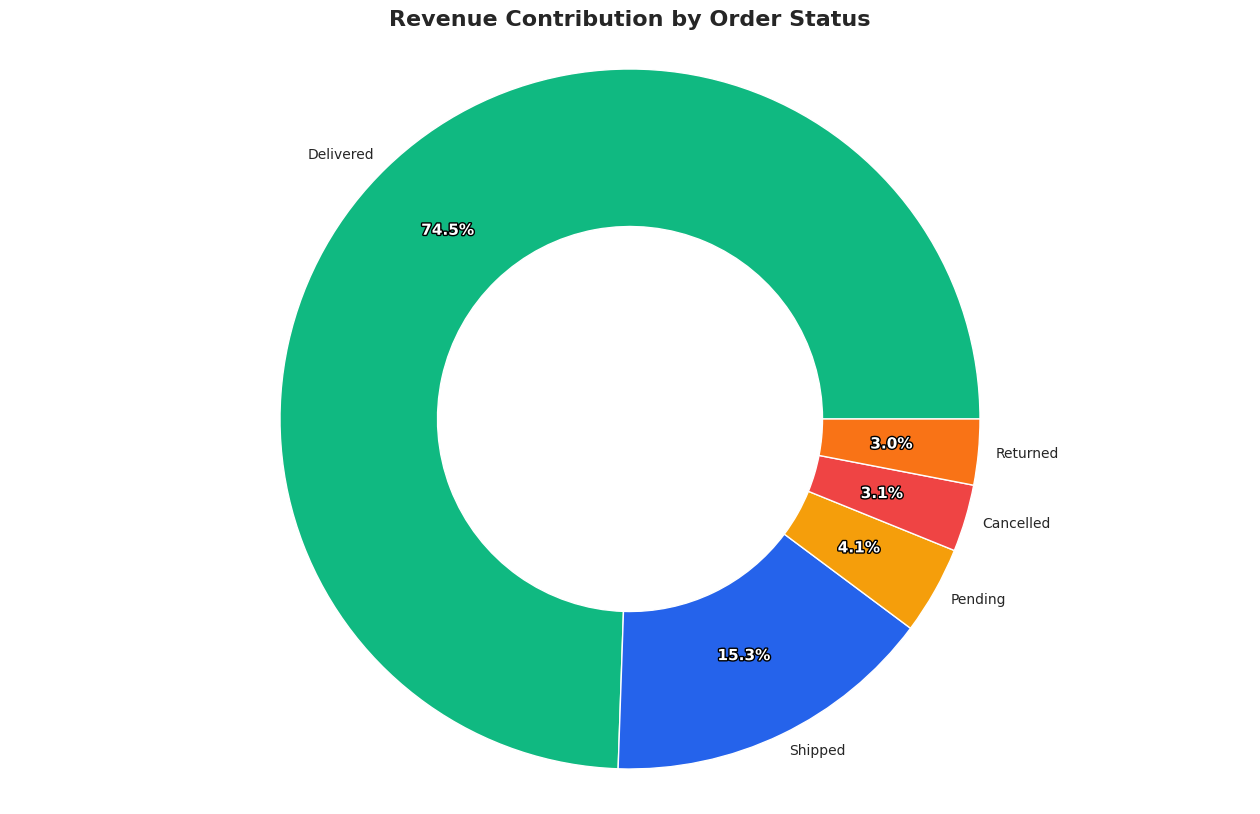

In [0]:
order_status_pdf = order_status_dist.select(
    "OrderStatus", "RevenuePercent"
).orderBy("RevenuePercent", ascending=False).toPandas()

plt.figure(figsize=(16,10))

custom_colors = {
    "Delivered": "#10B981",   # Emerald 
    "Shipped": "#2563EB",     # Royal Blue
    "Pending": "#F59E0B",     # Amber
    "Cancelled": "#EF4444",   # Red 
    "Returned": "#F97316"     # Orange
}
color_list = [
    custom_colors[status] 
    for status in order_status_pdf["OrderStatus"]
]

wedges, texts, autotexts = plt.pie(
    order_status_pdf["RevenuePercent"],
    labels=order_status_pdf["OrderStatus"],
    autopct='%1.1f%%',
    colors=color_list,
    wedgeprops=dict(width=0.45),
    pctdistance=0.75,
    labeldistance=1.05
)

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(11)
    autotext.set_fontweight("bold")
    autotext.set_path_effects([
        path_effects.Stroke(linewidth=2, foreground='black'),
        path_effects.Normal()
    ])

plt.title("Revenue Contribution by Order Status", fontsize=16, fontweight='bold')
plt.axis("equal")
plt.show()

### Delivery Success Rate

To evaluate the efficiency of the fulfillment process, we calculate the **delivery success rate**, defined as:

Delivery Success Rate = (Delivered Orders / Total Orders) × 100

A high delivery success rate indicates strong operational performance and reliable logistics.

In [0]:
total_orders = df.count()

delivered_orders = df.filter(f.col("OrderStatus") == "Delivered").count()

delivery_rate = round((delivered_orders / total_orders) * 100, 2)

print(f"Delivery Success Rate: {delivery_rate}%")

Delivery Success Rate: 74.63%


## 📌 Key Insights

- Credit cards generate the largest share of total revenue, indicating strong customer preference for card-based payments.
- Digital payment methods also contribute significantly, reflecting the growing adoption of online payment platforms.
- Most revenue comes from **successfully delivered orders**, which indicates a healthy fulfillment process.
- Cancelled and returned orders represent a smaller portion of revenue but still highlight areas for operational improvement.
- The delivery success rate confirms that the majority of orders are successfully completed.

These insights can support improvements in **payment strategy, logistics management, and customer experience optimization**.


## 🧾 EDA Summary

This exploratory analysis revealed several key patterns in the Amazon sales dataset:

- Revenue is concentrated in a few dominant product categories and brands.
- A small group of customers contributes a large share of total revenue.
- Sales exhibit quarterly trends that may indicate seasonal demand.
- Certain geographic regions drive the majority of revenue.
- Payment preferences and delivery success rates provide insights into customer behavior and operational performance.

These findings can guide future work such as predictive modeling, customer segmentation, and sales forecasting.